# Lab 6 — Spinning & Rolling Objects

**Name:** Matthew Nallar  
**Date:** October 4, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

***Part A***

In [2]:
def rotate_step(theta, omega, torque, I, dt):
    """Euler-Cromer step for rotation."""
    alpha = torque / I
    omega = omega + alpha * dt      # angular velocity first
    theta = theta + omega * dt      # then angle (Euler-Cromer)
    return theta, omega

# Physical Parameters
L = 1
m, g, d = 1.0, 9.81, L/2


I = (1/3) * m * (2*d)**2    # rod of length 2d about its end


def torque(theta):
    return -m * g * d * np.sin(theta)

In [3]:
def simulate(theta_initial, omega_initial, dt, steps):

    theta = theta_initial
    omega = omega_initial

    t_arr = np.zeros(steps + 1)
    theta_arr = np.zeros(steps + 1)
    omega_arr = np.zeros(steps + 1)

    theta_arr[0] = theta
    omega_arr[0] = omega

    for i in range(steps):

        theta, omega = rotate_step(
            theta,
            omega,
            torque(theta),
            I,
            dt
        
            
        )

        t_arr[i + 1] = t_arr[i] + dt
        theta_arr[i + 1] = theta
        omega_arr[i + 1] = omega

    return t_arr, theta_arr, omega_arr

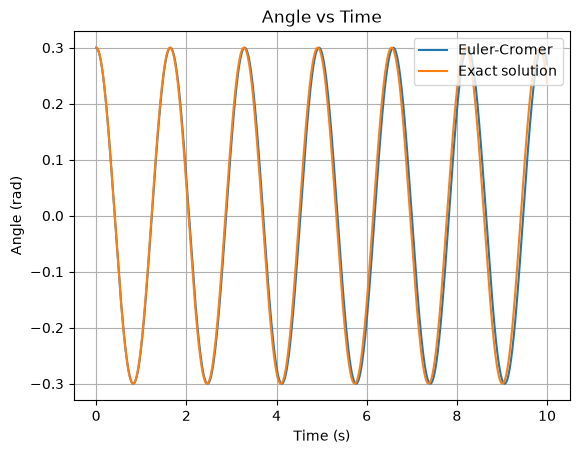

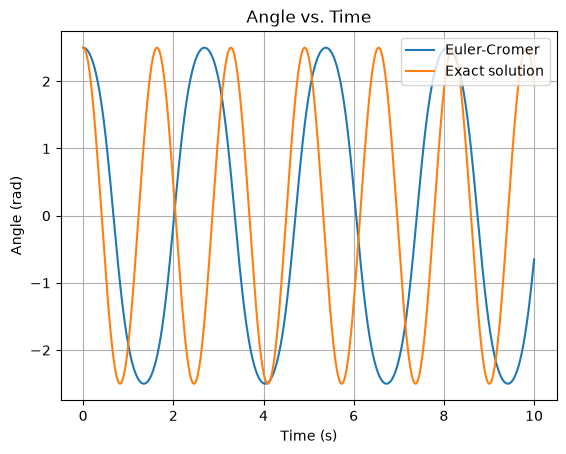

In [4]:
dt = 0.001
steps = 10000


t1, theta1, omega1 = simulate(
    0.3, 0.0, dt, steps

)

t2, theta2, omega2 = simulate(
    2.5, 0.0, dt, steps

)

exact_theta1 = 0.3 * np.cos(np.sqrt(m*g*d/I) * t1)
exact_theta2 = 2.5 * np.cos(np.sqrt(m*g*d/I) * t2)


plt.figure()
plt.title("Angle vs Time")
plt.plot(t1, theta1, label='Euler-Cromer')
plt.plot(t1, exact_theta1,'-', label='Exact solution')
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()


plt.figure()
plt.title("Angle vs. Time")
plt.plot(t2, theta2, label='Euler-Cromer')
plt.plot(t1, exact_theta2,'-', label='Exact solution')
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

**At large amplitude, is the real period longer or shorter than the small-angle prediction? Explain the connection to the nonlinear pendulum you saw in Lab 3.**

The real period is shorter than the small-angle prediction. If you approximate using small angle approximation, the pendulum equation reduces to the SHO and gives a constant period. But for large angles, the full sin(theta) makes the equation nonlinear, so the period becomes amplitude-dependent and is longer than the small-angle prediction. There is no simple elementary closed-form solution for the motion, which is another place where numerical methods such as Euler-Cromer are useful.

***Part B***

In [7]:
def rolling_accel(theta_incline, c, g=9.81):
    """Linear acceleration down an incline for a rolling body.
    c = I/(m R^2): hoop=1, disk=0.5, sphere=0.4."""
    return g * np.sin(theta_incline) / (1 + c)

def moment_of_inertia(masses, positions, axis):
    """I about a given axis point for a set of point masses."""
    total = 0.0
    for m, r in zip(masses, positions):
        total += m * np.sum((np.asarray(r) - np.asarray(axis))**2)
    return total

def rotate_step(theta, omega, torque, I, dt):
    """Euler-Cromer step for rotation."""
    alpha = torque / I
    omega = omega + alpha * dt      # angular velocity first
    theta = theta + omega * dt      # then angle (Euler-Cromer)
    return theta, omega


In [8]:
theta_incline = np.radians(30)
ramp_length = 10.0
g = 9.81

bodies = {
    "Sphere": 0.4,
    "Disk": 0.5,
    "Hoop": 1.0
}

Sphere
  acceleration = 3.5035714285714286 m/s^2
  finish time = 2.38923853022931 s
Disk
  acceleration = 3.2699999999999996 m/s^2
  finish time = 2.47309683414749 s
Hoop
  acceleration = 2.4524999999999997 m/s^2
  finish time = 2.855686245854129 s


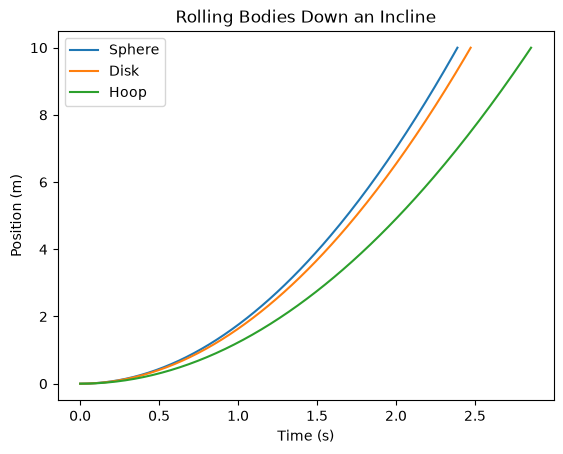

In [9]:
accelerations = {}
finish_times = {}

for body, c in bodies.items():
    a = rolling_accel(theta_incline, c, g)
    t_finish = np.sqrt(2 * ramp_length / a)

    accelerations[body] = a
    finish_times[body] = t_finish

    print(body)
    print("  acceleration =", a, "m/s^2")
    print("  finish time =", t_finish, "s")

plt.figure()

for body, c in bodies.items():
    a = accelerations[body]
    
    t = np.linspace(0, finish_times[body], 200)
    x = 0.5 * a * t**2
    
    plt.plot(t, x, label=body)

plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Rolling Bodies Down an Incline")
plt.legend()
plt.show()

In [11]:
m = 1.0
R = 0.2
c = 0.4

a = rolling_accel(theta_incline, c, g)

t = np.linspace(0, finish_times["Sphere"], 200)

x = 0.5 * a * t**2
v = a * t

height = (ramp_length - x) * np.sin(theta_incline)

KE_trans = 0.5 * m * v**2
KE_rot = 0.5 * c * m * v**2
PE = m * g * height

E_total = KE_trans + KE_rot + PE


rotation_fraction = KE_rot[-1] / (KE_trans[-1] + KE_rot[-1])

print("Fraction of kinetic energy in rotation:", rotation_fraction)
print("Percentage:", 100 * rotation_fraction, "%")

Fraction of kinetic energy in rotation: 0.28571428571428575
Percentage: 28.571428571428577 %


**Explain why the order is sphere → disk → hoop regardless of mass or radius. Why does the mass cancel out entirely?**

The sphere reaches the bottom first, followed by the disk and then the hoop because the acceleration depends on 1/(1+c). The sphere has the smallest value of c, so it has the greatest acceleration. Mass cancels because the rotational inertia has the form I=cmR^2, causing the mass and radius to cancel when substituted into the rolling-acceleration equation. Thus, objects of the same shape roll at the same rate regardless of their mass or radius.

***Part C***

In [12]:
def angular_momentum(I, omega):
    """Angular momentum of a spinning body."""
    return I * omega


def rotational_ke(I, omega):
    """Rotational kinetic energy."""
    return 0.5 * I * omega**2

In [16]:
I0 = 4.0
omega0 = 2.0

I_final = 0.5 * I0

t_total = 10.0
dt = 0.01

t_change_start = 4.0
t_change_end = 5.0

steps = int(t_total / dt) + 1
t = np.linspace(0, t_total, steps)

L0 = I0 * omega0

print("Initial angular momentum:", L0)
print("Initial moment of interia:", I0)

Initial angular momentum: 8.0
Initial moment of interia: 4.0


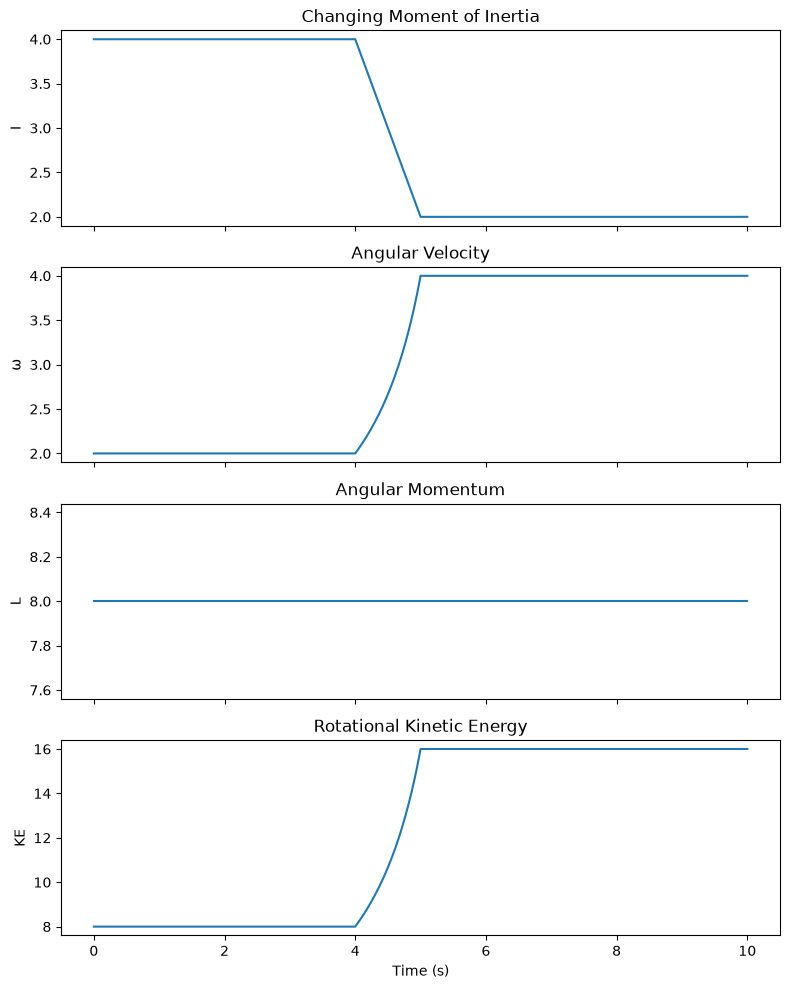

In [14]:
I = np.zeros(steps)
omega = np.zeros(steps)
L = np.zeros(steps)
KE_rot = np.zeros(steps)

for i in range(steps):

    if t[i] < t_change_start:
        I[i] = I0

    elif t[i] <= t_change_end:
        fraction = (t[i] - t_change_start) / (t_change_end - t_change_start)
        I[i] = I0 + fraction * (I_final - I0)

    else:
        I[i] = I_final

    # Enforce conservation of angular momentum
    omega[i] = L0 / I[i]

    # Calculate angular momentum and rotational KE
    L[i] = angular_momentum(I[i], omega[i])
    KE_rot[i] = rotational_ke(I[i], omega[i])


fig, ax = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

ax[0].plot(t, I)
ax[0].set_ylabel("I")
ax[0].set_title("Changing Moment of Inertia")

ax[1].plot(t, omega)
ax[1].set_ylabel("ω")
ax[1].set_title("Angular Velocity")

ax[2].plot(t, L)
ax[2].set_ylabel("L")
ax[2].set_title("Angular Momentum")

ax[3].plot(t, KE_rot)
ax[3].set_ylabel("KE")
ax[3].set_xlabel("Time (s)")
ax[3].set_title("Rotational Kinetic Energy")

plt.tight_layout()
plt.show()

**L stays constant, ω rises when I drops, but KE increases.  Where does the extra kinetic energy come from?  Why doesn't this violate energy conservation?**

Angular momentum is conserved because there is no external torque, but mechanical kinetic energy does not have to be conserved when the skater actively changes their moment of inertia.

**List the three conservation laws you've now used as diagnostics across the course (energy, linear momentum, angular momentum) and give one example of a bug each one would catch.**

1. *Energy conservation*
   - Total energy should remain constant when there is no external work or dissipation.
   - A violation could indicate an incorrect force, potential-energy equation, or numerical integration bug.
   - Example: an orbit that continuously gains or loses energy could indicate an integration error.

2. *Linear momentum conservation*
   - Total linear momentum should remain constant when there is no external force.
   - A violation could indicate an incorrect collision calculation or an unintended external force.
   - Example: if the center of mass of a collision system accelerates without an external force, momentum may not be conserved.

3. *Angular momentum conservation*
   - Angular momentum should remain constant when there is no external torque.
   - A violation could indicate an incorrect torque or rotational update.
   - Example: if a torque-free spinning body changes its angular momentum when its moment of inertia changes, the simulation is incorrect.